In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def alpha_n(V):
    return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))

def beta_n(V):
    return 0.125 * np.exp(-(V + 65) / 80)

def alpha_m(V):
    return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))

def beta_m(V):
    return 4.0 * np.exp(-(V + 65) / 18)

def alpha_h(V):
    return 0.07 * np.exp(-(V + 65) / 20)

def beta_h(V):
    return 1 / (1 + np.exp(-(V + 35) / 10))

In [3]:
# --- Ionic currents ---
def I_Na(V, m, h, g_Na=120.0, E_Na=50.0):
    return g_Na * m**3 * h * (V - E_Na)

def I_K(V, n, g_K=36.0, E_K=-77.0):
    return g_K * n**4 * (V - E_K)

def I_L(V, g_L=0.3, E_L=-54.387):
    return g_L * (V - E_L)

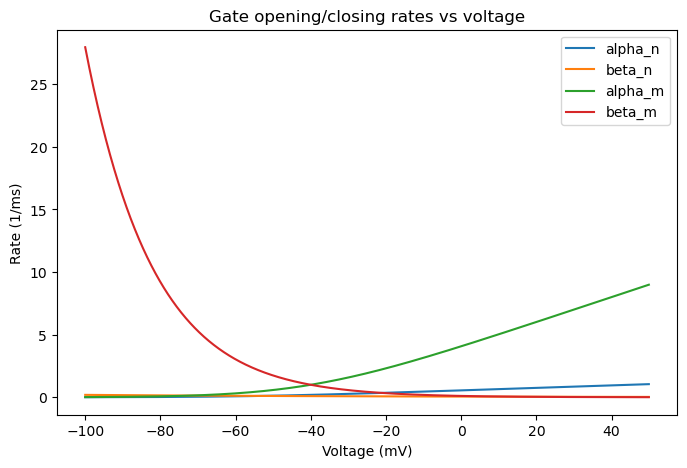

In [4]:
V_range = np.arange(-100, 50, 0.1)

plt.figure(figsize=(8,5))
plt.plot(V_range, alpha_n(V_range), label='alpha_n')
plt.plot(V_range, beta_n(V_range), label='beta_n')
plt.plot(V_range, alpha_m(V_range), label='alpha_m')
plt.plot(V_range, beta_m(V_range), label='beta_m')
plt.xlabel("Voltage (mV)")
plt.ylabel("Rate (1/ms)")
plt.title("Gate opening/closing rates vs voltage")
plt.legend()
plt.show()

In [5]:
def steady_state_gates(V):
    n0 = alpha_n(V) / (alpha_n(V) + beta_n(V))
    m0 = alpha_m(V) / (alpha_m(V) + beta_m(V))
    h0 = alpha_h(V) / (alpha_h(V) + beta_h(V))
    return n0, m0, h0

V_rest = -65.0
n0, m0, h0 = steady_state_gates(V_rest)
print(f"n0 = {n0:.4f}, m0 = {m0:.4f}, h0 = {h0:.4f}")

n0 = 0.3177, m0 = 0.0529, h0 = 0.5961


In [6]:
C_m = 1.0  # membrane capacitance (uF/cm^2)

def derivatives(state, I_ext):
    V, n, m, h = state
    dVdt = (I_ext - I_Na(V, m, h) - I_K(V, n) - I_L(V)) / C_m
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    return np.array([dVdt, dndt, dmdt, dhdt])

def simulate(t, I_ext_func, V0=-65.0):
    dt = t[1] - t[0]
    n0, m0, h0 = steady_state_gates(V0)
    state = np.array([V0, n0, m0, h0])

    V_trace = np.zeros(len(t))
    n_trace = np.zeros(len(t))
    m_trace = np.zeros(len(t))
    h_trace = np.zeros(len(t))

    for i, ti in enumerate(t):
        V_trace[i], n_trace[i], m_trace[i], h_trace[i] = state
        I = I_ext_func(ti)

        # RK4 integration step
        k1 = derivatives(state, I)
        k2 = derivatives(state + dt/2 * k1, I_ext_func(ti + dt/2))
        k3 = derivatives(state + dt/2 * k2, I_ext_func(ti + dt/2))
        k4 = derivatives(state + dt * k3, I_ext_func(ti + dt))
        state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

    return V_trace, n_trace, m_trace, h_trace

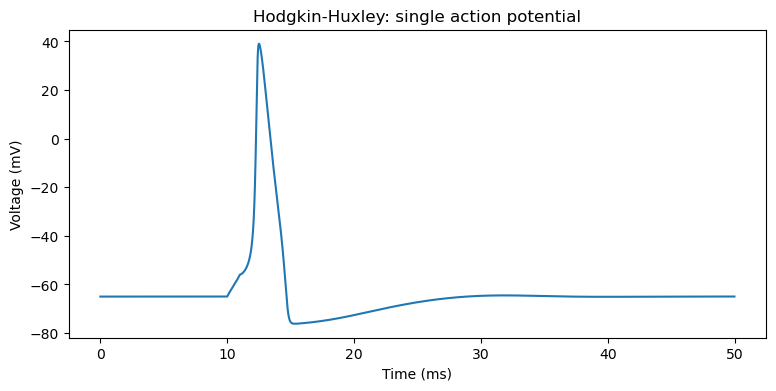

In [7]:
t = np.arange(0, 50, 0.01)  # ms, small dt for stability

def I_ext_func(ti):
    return 10.0 if 10 <= ti <= 11 else 0.0  # short strong pulse

V_trace, n_trace, m_trace, h_trace = simulate(t, I_ext_func)

plt.figure(figsize=(9,4))
plt.plot(t, V_trace)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Hodgkin-Huxley: single action potential")
plt.show()

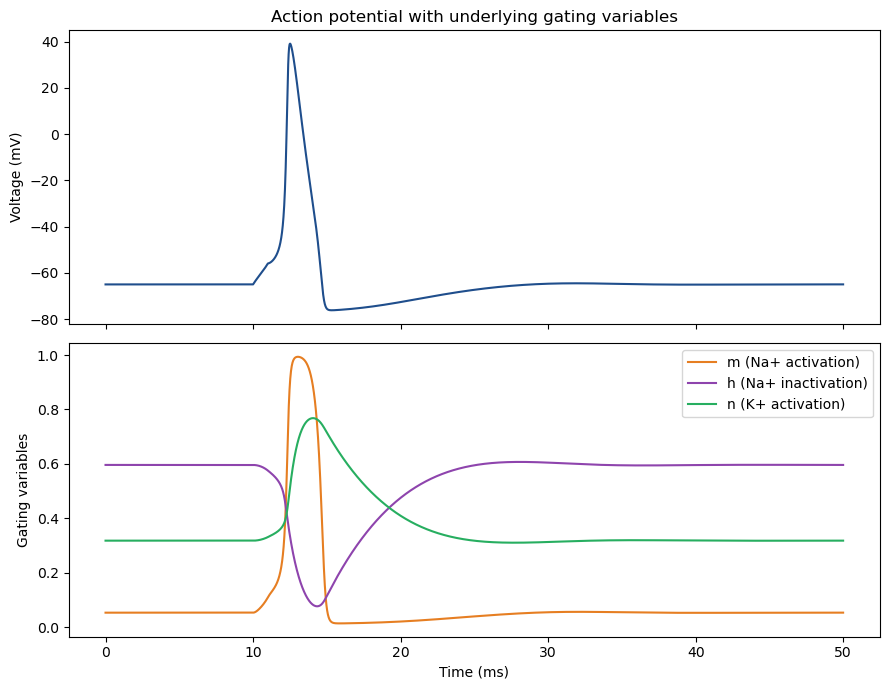

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(t, V_trace, color='#1f4e8c')
ax1.set_ylabel("Voltage (mV)")
ax1.set_title("Action potential with underlying gating variables")

ax2.plot(t, m_trace, label='m (Na+ activation)', color='#e67e22')
ax2.plot(t, h_trace, label='h (Na+ inactivation)', color='#8e44ad')
ax2.plot(t, n_trace, label='n (K+ activation)', color='#27ae60')
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Gating variables")
ax2.legend()

plt.tight_layout()
plt.show()

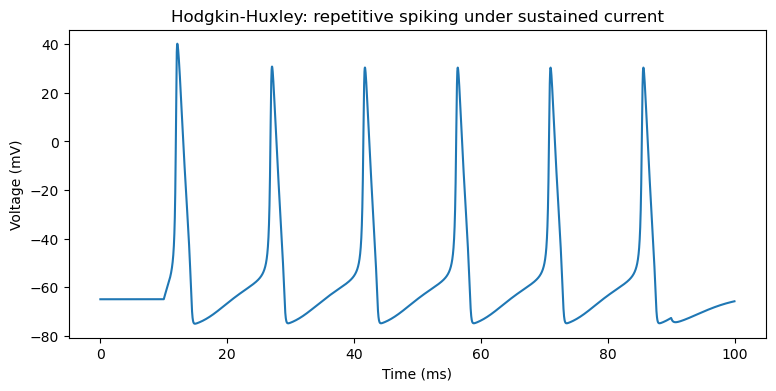

In [9]:
t = np.arange(0, 100, 0.01)

def I_ext_func(ti):
    return 10.0 if 10 <= ti <= 90 else 0.0  # sustained current

V_trace, n_trace, m_trace, h_trace = simulate(t, I_ext_func)

plt.figure(figsize=(9,4))
plt.plot(t, V_trace)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Hodgkin-Huxley: repetitive spiking under sustained current")
plt.show()

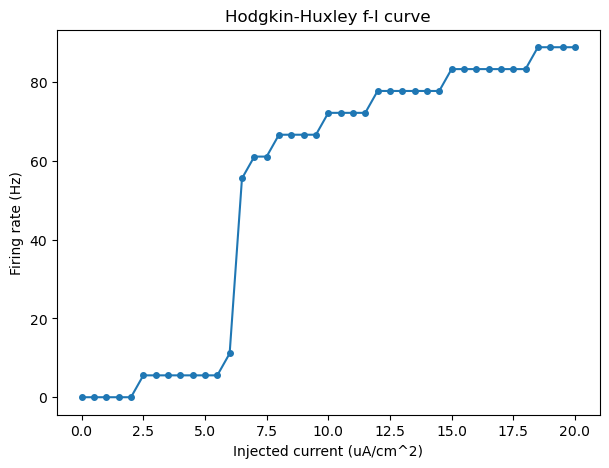

In [10]:
def count_spikes(V_trace, threshold=0.0):
    above = V_trace > threshold
    crossings = np.where(np.diff(above.astype(int)) == 1)[0]
    return len(crossings)

t = np.arange(0, 200, 0.01)
currents = np.arange(0, 20.5, 0.5)
firing_rates = []

for I_amp in currents:
    def I_ext_func(ti, amp=I_amp):
        return amp if 10 <= ti <= 190 else 0.0
    V_trace, n_trace, m_trace, h_trace = simulate(t, I_ext_func)
    n_spikes = count_spikes(V_trace)
    duration_s = (190 - 10) / 1000.0
    firing_rates.append(n_spikes / duration_s)

plt.figure(figsize=(7,5))
plt.plot(currents, firing_rates, marker='o', markersize=4)
plt.xlabel("Injected current (uA/cm^2)")
plt.ylabel("Firing rate (Hz)")
plt.title("Hodgkin-Huxley f-I curve")
plt.show()

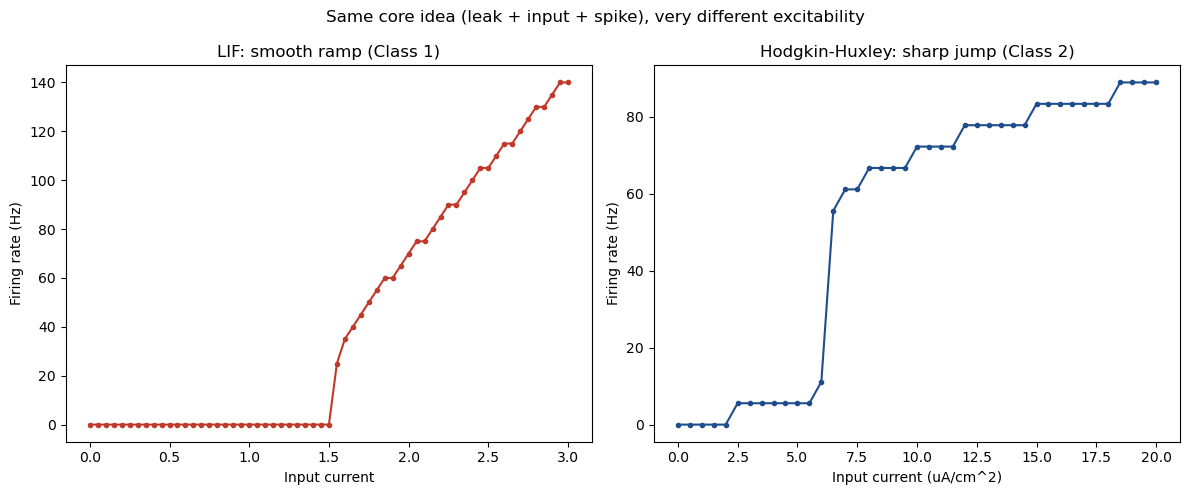

In [11]:
# LIF setup (reusing constants from your earlier LIF work)
V_rest_lif = -65.0
tau = 10.0
R = 10.0
V_threshold_lif = -50.0
V_reset_lif = -65.0

def lif_spike_count(I, T=200, dt=0.01):
    t = np.arange(0, T, dt)
    V = V_rest_lif
    spikes = 0
    for ti in t:
        if V >= V_threshold_lif:
            spikes += 1
            V = V_reset_lif
        else:
            dVdt = (-(V - V_rest_lif) + R * I) / tau
            V = V + dVdt * dt
    return spikes

lif_currents = np.arange(0, 3.05, 0.05)
lif_rates = [lif_spike_count(I) / 0.2 for I in lif_currents]  # 200ms = 0.2s

# Plot both, using each model's own current scale (they're not the same units in this simplified comparison)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lif_currents, lif_rates, marker='o', markersize=3, color='#c0392b')
axes[0].set_title("LIF: smooth ramp (Class 1)")
axes[0].set_xlabel("Input current")
axes[0].set_ylabel("Firing rate (Hz)")

axes[1].plot(currents, firing_rates, marker='o', markersize=3, color='#1f4e8c')
axes[1].set_title("Hodgkin-Huxley: sharp jump (Class 2)")
axes[1].set_xlabel("Input current (uA/cm^2)")
axes[1].set_ylabel("Firing rate (Hz)")

plt.suptitle("Same core idea (leak + input + spike), very different excitability")
plt.tight_layout()
plt.show()